# **Install Dependecies**

In [1]:
!pip install -q albumentations opencv-python-headless matplotlib

# **Import Required Libraries**

In [2]:
import os
import time
import random
import shutil
from pathlib import Path
from collections import defaultdict
import tracemalloc

import numpy as np
import cv2
from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast

from torchvision.io import read_image
from torchvision.transforms.functional import convert_image_dtype
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

from torchmetrics.detection.mean_ap import MeanAveragePrecision

# **Config**

In [3]:
num_classes = 4  # background + 3 defect classes

train_root = "/kaggle/input/railway-datasets/Railway_Train"
val_root   = "/kaggle/input/railway-datasets/Railway_Val"
test_root  = "/kaggle/input/railway-datasets/Railway_Test"

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("✅ Using device:", device)

✅ Using device: cuda


# **Dataset Classes**

In [4]:
class RailDefectsDataset(Dataset):
    def __init__(self, root_dir):
        self.data = []
        self.class_map = {"Bolt": 1, "Fastener": 2, "Railcrack": 3}

        for cls, cls_id in self.class_map.items():
            img_dir = os.path.join(root_dir, cls, "images")
            lbl_dir = os.path.join(root_dir, cls, "labels")

            if not os.path.isdir(img_dir):
                continue

            for img_name in os.listdir(img_dir):
                if img_name.lower().endswith((".jpg", ".png")):
                    img_path = os.path.join(img_dir, img_name)
                    lbl_path = os.path.join(lbl_dir, img_name.rsplit(".", 1)[0] + ".txt")
                    if os.path.exists(lbl_path):
                        self.data.append((img_path, lbl_path, cls_id))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, lbl_path, cls_id = self.data[idx]

        img = read_image(img_path).float() / 255.0
        if img.shape[0] == 1:
            img = img.repeat(3, 1, 1)

        h, w = img.shape[1:]
        boxes, labels = [], []

        with open(lbl_path) as f:
            for line in f:
                _, xc, yc, bw, bh = map(float, line.split())
                xmin = (xc - bw / 2) * w
                xmax = (xc + bw / 2) * w
                ymin = (yc - bh / 2) * h
                ymax = (yc + bh / 2) * h
                boxes.append([xmin, ymin, xmax, ymax])
                labels.append(cls_id)

        target = {
            "boxes": torch.tensor(boxes, dtype=torch.float32),
            "labels": torch.tensor(labels, dtype=torch.int64),
        }
        return img, target


def collate_fn(batch):
    return tuple(zip(*batch))

# **Load Train and Validation Dataset**

In [5]:
train_dataset = RailDefectsDataset(train_root)
val_dataset   = RailDefectsDataset(val_root)

from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=16,          # safer for GPU memory
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=2
)

print(f"✅ Train Dataset Ready")
print(f"✅ Validation Dataset Ready")

✅ Train Dataset Ready
✅ Validation Dataset Ready


# **Model**

In [6]:
model = fasterrcnn_resnet50_fpn(weights="DEFAULT")
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
model = model.to(device)
print("✅ Faster R-CNN Model Ready on", device)

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:00<00:00, 204MB/s] 


✅ Faster R-CNN Model Ready on cuda


# **Optimizer & Schduler**

In [7]:
params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

# **Training Loop**

In [8]:
num_epochs = 50
history = {"loss": [], "accuracy": [], "val_loss": [], "val_accuracy": []}
val_map_scores = []
metric = MeanAveragePrecision()

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    correct_train, total_train = 0, 0
    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} Training", leave=False)
    for images, targets in progress_bar:
        images = [img.repeat(3,1,1) if img.shape[0]!=3 else img for img in images]
        images = [img.to(device) for img in images]
        targets = [{k:v.to(device) for k,v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        loss = sum(loss_dict.values())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

        model.eval()
        with torch.no_grad():
            outputs = model(images)
            for t, o in zip(targets, outputs):
                gt_label = int(t["labels"][0].item()) if len(t["labels"])>0 else 0
                pred_label = int(o["labels"][0].item()) if len(o["labels"])>0 else 0
                if gt_label == pred_label:
                    correct_train += 1
                total_train += 1
        model.train()

    avg_train_loss = epoch_loss / len(train_loader)
    train_acc = correct_train / total_train
    history["loss"].append(avg_train_loss)
    history["accuracy"].append(train_acc)

    # Validation
    model.eval()
    val_loss_epoch, correct_val, total_val = 0.0, 0, 0
    metric.reset()
    with torch.no_grad():
        for images, targets in val_loader:
            images = [img.repeat(3,1,1) if img.shape[0]!=3 else img for img in images]
            images = [img.to(device) for img in images]
            targets_device = [{k:v.to(device) for k,v in t.items()} for t in targets]
            model.train()
            with torch.no_grad():
                loss_dict = model(images, targets_device)
                val_loss = sum(loss_dict.values())
                val_loss_epoch += val_loss.item()
            model.eval()
            outputs = model(images)
            for t, o in zip(targets, outputs):
                gt_label = int(t["labels"][0].item()) if len(t["labels"])>0 else 0
                pred_label = int(o["labels"][0].item()) if len(o["labels"])>0 else 0
                if gt_label == pred_label:
                    correct_val += 1
                total_val += 1
            outputs_cpu = [{k:v.cpu() for k,v in o.items()} for o in outputs]
            metric.update(outputs_cpu, targets)
    val_loss_epoch /= len(val_loader)
    val_acc = correct_val / total_val
    val_map = metric.compute()["map"].item()
    history["val_loss"].append(val_loss_epoch)
    history["val_accuracy"].append(val_acc)
    val_map_scores.append(val_map)
    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {avg_train_loss:.4f} | Val Loss: {val_loss_epoch:.4f} | "
          f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Val mAP: {val_map:.4f}")

Epoch 1/50 Training:   0%|          | 0/113 [00:00<?, ?it/s]

Epoch 1/50 | Train Loss: 0.2913 | Val Loss: 0.1666 | Train Acc: 0.6589 | Val Acc: 0.9283 | Val mAP: 0.3459


Epoch 2/50 Training:   0%|          | 0/113 [00:00<?, ?it/s]

Epoch 2/50 | Train Loss: 0.1410 | Val Loss: 0.1230 | Train Acc: 0.9622 | Val Acc: 0.9450 | Val mAP: 0.5111


Epoch 3/50 Training:   0%|          | 0/113 [00:00<?, ?it/s]

...

Epoch 48/50 | Train Loss: 0.0184 | Val Loss: 0.1142 | Train Acc: 1.0000 | Val Acc: 0.9700 | Val mAP: 0.6227


Epoch 49/50 Training:   0%|          | 0/113 [00:00<?, ?it/s]

Epoch 49/50 | Train Loss: 0.0178 | Val Loss: 0.1155 | Train Acc: 1.0000 | Val Acc: 0.9700 | Val mAP: 0.6191


Epoch 50/50 Training:   0%|          | 0/113 [00:00<?, ?it/s]

Epoch 50/50 | Train Loss: 0.0176 | Val Loss: 0.1145 | Train Acc: 1.0000 | Val Acc: 0.9633 | Val mAP: 0.6169


# **Save Model**

In [10]:
torch.save(model.state_dict(), "/kaggle/working/fasterrcnn_raildefects.pth")
print("\n✅ Model saved at /kaggle/working/fasterrcnn_raildefects.pth")


✅ Model saved at /kaggle/working/fasterrcnn_raildefects.pth


# **Evaluation of the Model**

# Load Test Dataset

In [11]:
test_dataset = RailDefectsDataset(test_root)
test_loader = DataLoader(
    test_dataset, batch_size=8, shuffle=False, 
    collate_fn=collate_fn, num_workers=2
)

# Run Nodel Evaluation

In [12]:
from torchmetrics.detection.mean_ap import MeanAveragePrecision

model.eval()
metric = MeanAveragePrecision()
all_targets, all_preds = [], []

with torch.no_grad():
    for images, targets in tqdm(test_loader, desc="Evaluating on Test Set"):
        images = [img.to(device) for img in images]

        outputs = model(images)

        # TorchMetrics expects CPU tensors
        outputs_cpu = [{k: v.cpu() for k, v in o.items()} for o in outputs]
        targets_cpu = [{k: v.cpu() for k, v in t.items()} for t in targets]

        # Update detection metric
        metric.update(outputs_cpu, targets_cpu)

        # Collect labels (for confusion matrix / accuracy, optional)
        for t, o in zip(targets_cpu, outputs_cpu):
            gt_label = int(t["labels"][0]) if len(t["labels"]) > 0 else 0
            pred_label = int(o["labels"][0]) if len(o["labels"]) > 0 else 0
            all_targets.append(gt_label)
            all_preds.append(pred_label)

Evaluating on Test Set:   0%|          | 0/75 [00:00<?, ?it/s]

# Detection Metrics (mAP)

In [13]:
from torchvision.ops import box_iou

def evaluate_map50(model, dataloader, device, iou_thresh=0.5):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, targets in tqdm(dataloader, desc="Evaluating"):
            images = [img.to(device) for img in images]
            outputs = model(images)

            for o, t in zip(outputs, targets):
                if len(o["boxes"]) == 0 or len(t["boxes"]) == 0:
                    continue

                ious = box_iou(o["boxes"].cpu(), t["boxes"])
                max_iou, _ = ious.max(dim=1)

                correct += (max_iou >= iou_thresh).sum().item()
                total += len(t["boxes"])

    return correct / total if total > 0 else 0.0

In [22]:
results = metric.compute()

print("✅ Test Set Detection Metrics:")
print(f"mAP (50–95): {results['map']:.4f}")
print(f"mAP@0.5:     {results['map_50']:.4f}")
print(f"mAP@0.75:    {results['map_75']:.4f}")

✅ Test Set Detection Metrics:
mAP (50–95): 0.5929
mAP@0.5:     0.9026
mAP@0.75:    0.6707


# Overall Metrics

In [15]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

# Remove background samples (label = 0)
targets_filtered = []
preds_filtered = []

for gt, pred in zip(all_targets, all_preds):
    if gt != 0:                      # valid object exists
        targets_filtered.append(gt)
        preds_filtered.append(pred)  # may still be 0 (missed detection)

# Overall classification-style metrics
acc  = accuracy_score(targets_filtered, preds_filtered)
f1   = f1_score(targets_filtered, preds_filtered, average="weighted", zero_division=0)
prec = precision_score(targets_filtered, preds_filtered, average="weighted", zero_division=0)
rec  = recall_score(targets_filtered, preds_filtered, average="weighted", zero_division=0)

print("\n✅ Test Set Overall Metrics (Image-level):")
print(f"Accuracy    : {acc:.4f}")
print(f"F1 Score    : {f1:.4f}")
print(f"Precision   : {prec:.4f}")
print(f"Recall      : {rec:.4f}")


✅ Test Set Overall Metrics (Image-level):
Accuracy    : 0.9700
F1 Score    : 0.9756
Precision   : 0.9814
Recall      : 0.9700


# Per-class Metrics

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score

class_names = ['background', 'bolt', 'fastener', 'railcrack']

labels = [1, 2, 3]
names = class_names[1:]

print("\n✅ Per-Class Image-level Metrics:\n")

for label, name in zip(labels, names):
    precision = precision_score(
        targets_filtered,
        preds_filtered,
        labels=[label],
        average="macro",
        zero_division=0
    )
    recall = recall_score(
        targets_filtered,
        preds_filtered,
        labels=[label],
        average="macro",
        zero_division=0
    )
    f1 = f1_score(
        targets_filtered,
        preds_filtered,
        labels=[label],
        average="macro",
        zero_division=0
    )

    support = sum(t == label for t in targets_filtered)

    print(
        f"{name:<10} → "
        f"Precision: {precision:.4f}, "
        f"Recall: {recall:.4f}, "
        f"F1-score: {f1:.4f}, "
        f"Support: {support}"
    )


✅ Per-Class Image-level Metrics:

bolt       → Precision: 0.9794, Recall: 0.9500, F1-score: 0.9645, Support: 200
fastener   → Precision: 0.9648, Recall: 0.9600, F1-score: 0.9624, Support: 200
railcrack  → Precision: 1.0000, Recall: 1.0000, F1-score: 1.0000, Support: 200


# Confusion Matrix

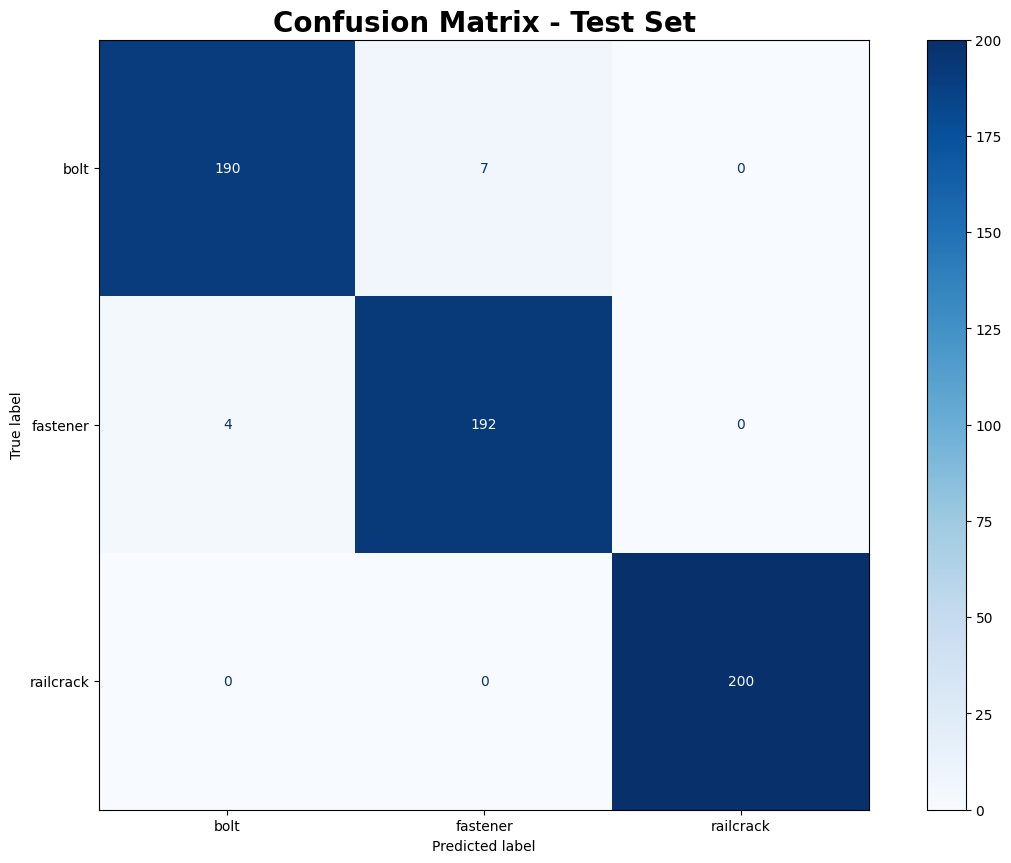

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    targets_filtered,
    preds_filtered,
    labels=labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=names
)

fig, ax = plt.subplots(figsize=(15, 10))
disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=True)
plt.title("Confusion Matrix - Test Set", fontsize=20, fontweight='bold')
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.show()

# Plotting Accuracy & Loss Curves

In [18]:
def plot_accuracy(history):
    epochs_range = range(len(history["accuracy"]))

    plt.figure(figsize=(10,5))
    plt.plot(epochs_range, history["accuracy"], label="Train Accuracy", marker='o')
    plt.plot(epochs_range, history["val_accuracy"], label="Val Accuracy", marker='o')

    plt.title("Accuracy", fontsize=12, fontweight='bold')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [19]:
def plot_loss(history):
    epochs_range = range(len(history["loss"]))

    plt.figure(figsize=(10,5))
    plt.plot(epochs_range, history["loss"], label="Train Loss", marker='o')
    plt.plot(epochs_range, history["val_loss"], label="Val Loss", marker='o')

    plt.title("Loss", fontsize=12, fontweight='bold')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

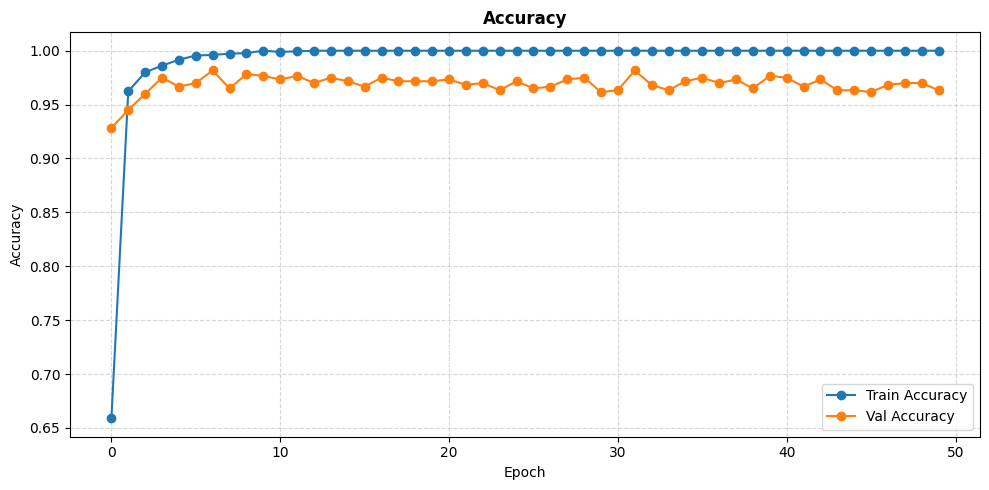

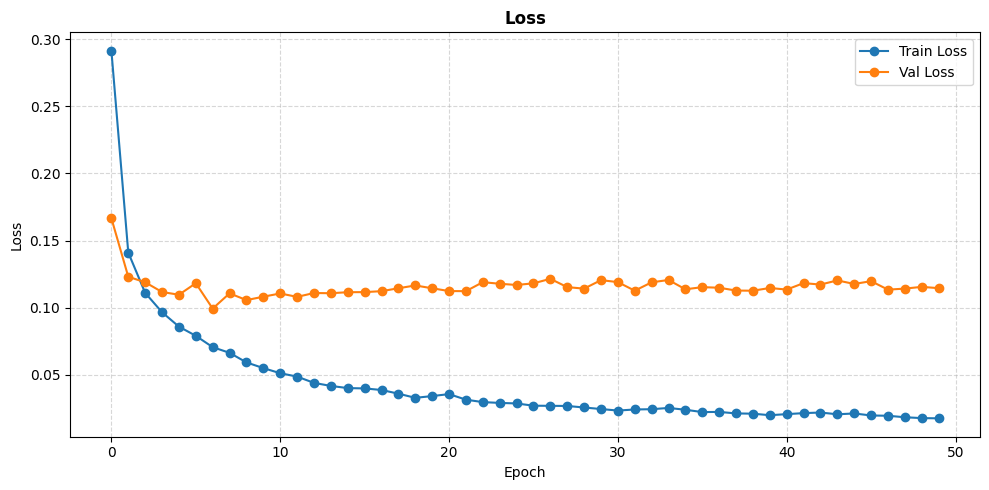

In [20]:
plot_accuracy(history)
plot_loss(history)

# **Visualization of Random Predictions**

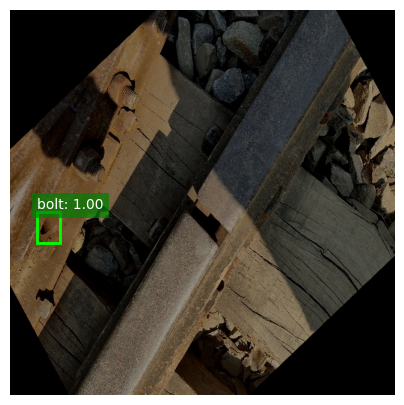

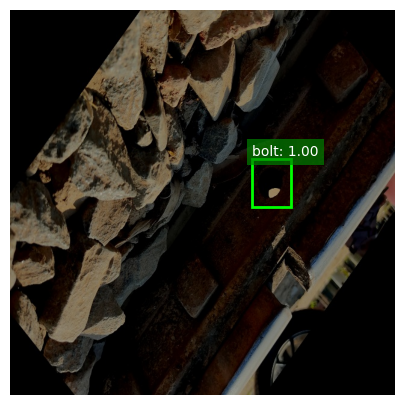

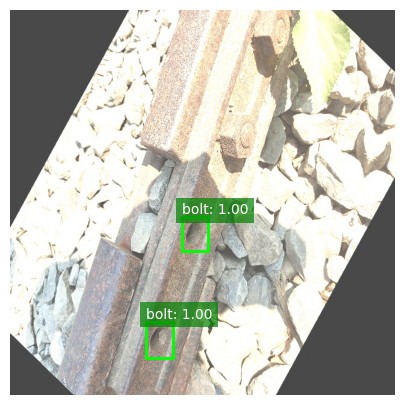

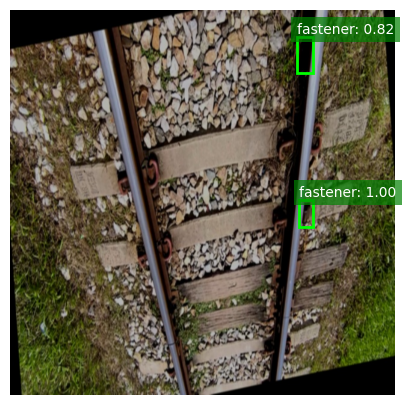

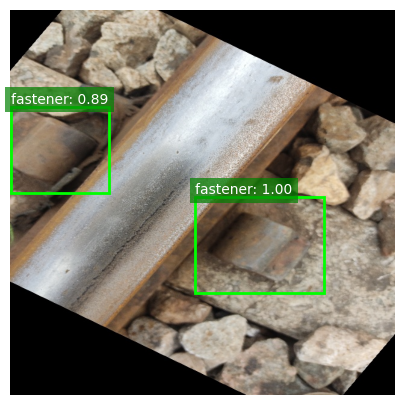

In [21]:
def visualize_predictions(img, boxes, labels, scores, threshold=0.5):
    fig, ax = plt.subplots(1, figsize=(5, 5))

    # Convert image tensor (C,H,W) to numpy (H,W,C)
    img_np = img.permute(1, 2, 0).numpy()

    # If normalized, undo normalization (optional)
    img_np = img_np.clip(0, 1)  # Ensure values between 0 and 1
    ax.imshow(img_np)

    # Draw predictions above threshold
    for box, label, score in zip(boxes, labels, scores):
        if score >= threshold:
            xmin, ymin, xmax, ymax = box
            rect = patches.Rectangle(
                (xmin, ymin),
                xmax - xmin,
                ymax - ymin,
                linewidth=2,
                edgecolor='lime',
                facecolor='none'
            )
            ax.add_patch(rect)

            # Display class name and score
            ax.text(
                xmin,
                ymin - 5,
                f"{class_names[label]}: {score:.2f}",
                color='white',
                fontsize=10,
                bbox=dict(facecolor='green', alpha=0.7, edgecolor='none')
            )

    plt.axis("off")
    plt.show()


# Show 5 random predictions from test set
model.eval()
with torch.no_grad():
    for _ in range(5):
        idx = random.randint(0, len(test_dataset) - 1)
        img, _ = test_dataset[idx]

        # Send image to device and run model
        output = model([img.to(device)])[0]

        # Visualize predictions
        visualize_predictions(
            img.cpu(),
            output["boxes"].cpu(),
            output["labels"].cpu(),
            output["scores"].cpu(),
            threshold=0.5
        )